I. DATA UNDERSTANDING

In [112]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

II. EXPLORATORY DATA ANALYSIS

In [113]:
dataset = pd.read_csv('diabetes_data_upload.csv')
dataset

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,39,Female,Yes,Yes,Yes,No,Yes,No,No,Yes,No,Yes,Yes,No,No,No,Positive
516,48,Female,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,No,No,No,Positive
517,58,Female,Yes,Yes,Yes,Yes,Yes,No,Yes,No,No,No,Yes,Yes,No,Yes,Positive
518,32,Female,No,No,No,Yes,No,No,Yes,Yes,No,Yes,No,No,Yes,No,Negative


In [114]:
dataset.columns

Index(['Age', 'Gender', 'Polyuria', 'Polydipsia', 'sudden weight loss',
       'weakness', 'Polyphagia', 'Genital thrush', 'visual blurring',
       'Itching', 'Irritability', 'delayed healing', 'partial paresis',
       'muscle stiffness', 'Alopecia', 'Obesity', 'class'],
      dtype='str')

In [115]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Age                 520 non-null    int64
 1   Gender              520 non-null    str  
 2   Polyuria            520 non-null    str  
 3   Polydipsia          520 non-null    str  
 4   sudden weight loss  520 non-null    str  
 5   weakness            520 non-null    str  
 6   Polyphagia          520 non-null    str  
 7   Genital thrush      520 non-null    str  
 8   visual blurring     520 non-null    str  
 9   Itching             520 non-null    str  
 10  Irritability        520 non-null    str  
 11  delayed healing     520 non-null    str  
 12  partial paresis     520 non-null    str  
 13  muscle stiffness    520 non-null    str  
 14  Alopecia            520 non-null    str  
 15  Obesity             520 non-null    str  
 16  class               520 non-null    str  
dtypes: int64

In [116]:
dataset.isna().sum()

Age                   0
Gender                0
Polyuria              0
Polydipsia            0
sudden weight loss    0
weakness              0
Polyphagia            0
Genital thrush        0
visual blurring       0
Itching               0
Irritability          0
delayed healing       0
partial paresis       0
muscle stiffness      0
Alopecia              0
Obesity               0
class                 0
dtype: int64

In [117]:
dataset.duplicated().sum()

np.int64(269)

In [118]:
dataset.describe()

,Age
count,520.000000
mean,48.028846
std,12.151466
min,16.000000
25%,39.000000
50%,47.500000
75%,57.000000
max,90.000000


In [119]:
map_target = {"Positive" : 1, "Negative" : 0}
map_yes_no = {"Yes" : 1, "No" : 0}
map_gender = {"Female" : 1, "Male" : 0}

dataset['class'] = dataset['class'].map(map_target)
cols = ['Polyuria', 'Polydipsia', 'sudden weight loss', 'weakness', 'Polyphagia', 'Genital thrush', 'visual blurring', 'Itching', 'Irritability', 'delayed healing', 'partial paresis', 'muscle stiffness', 'Alopecia', 'Obesity']
dataset[cols] = dataset[cols].replace(map_yes_no)
dataset['Gender'] = dataset['Gender'].map(map_gender)

In [120]:
target_count = dataset['class'].value_counts()
target_count


class
1    320
0    200
Name: count, dtype: int64

C:\Users\nizam\AppData\Local\Temp\ipykernel_14932\206164463.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=dataset, palette="coolwarm")


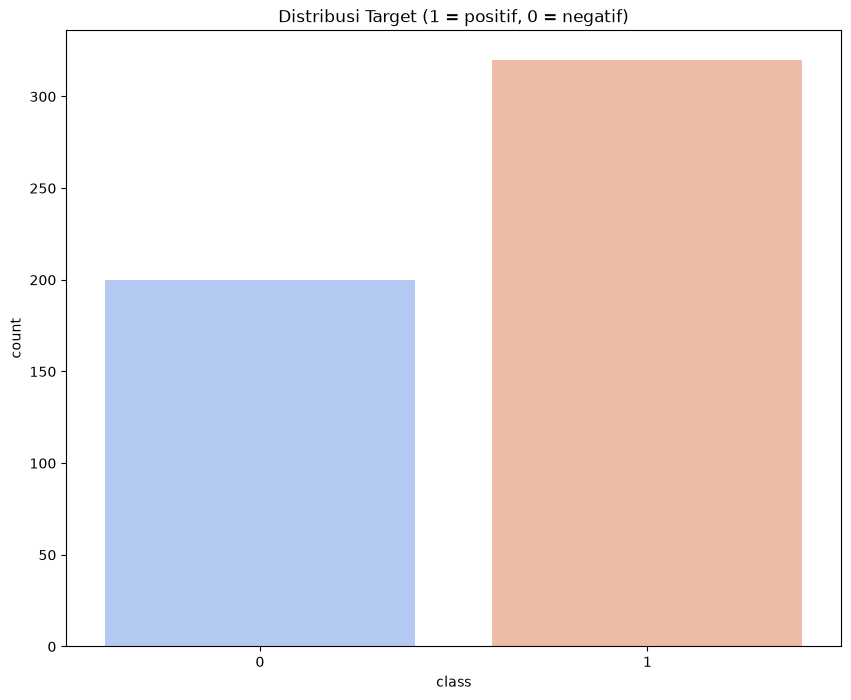

In [121]:
plt.figure(figsize=(10,8))
sns.countplot(x='class', data=dataset, palette="coolwarm")
plt.title("Distribusi Target (1 = positif, 0 = negatif)")
plt.show()

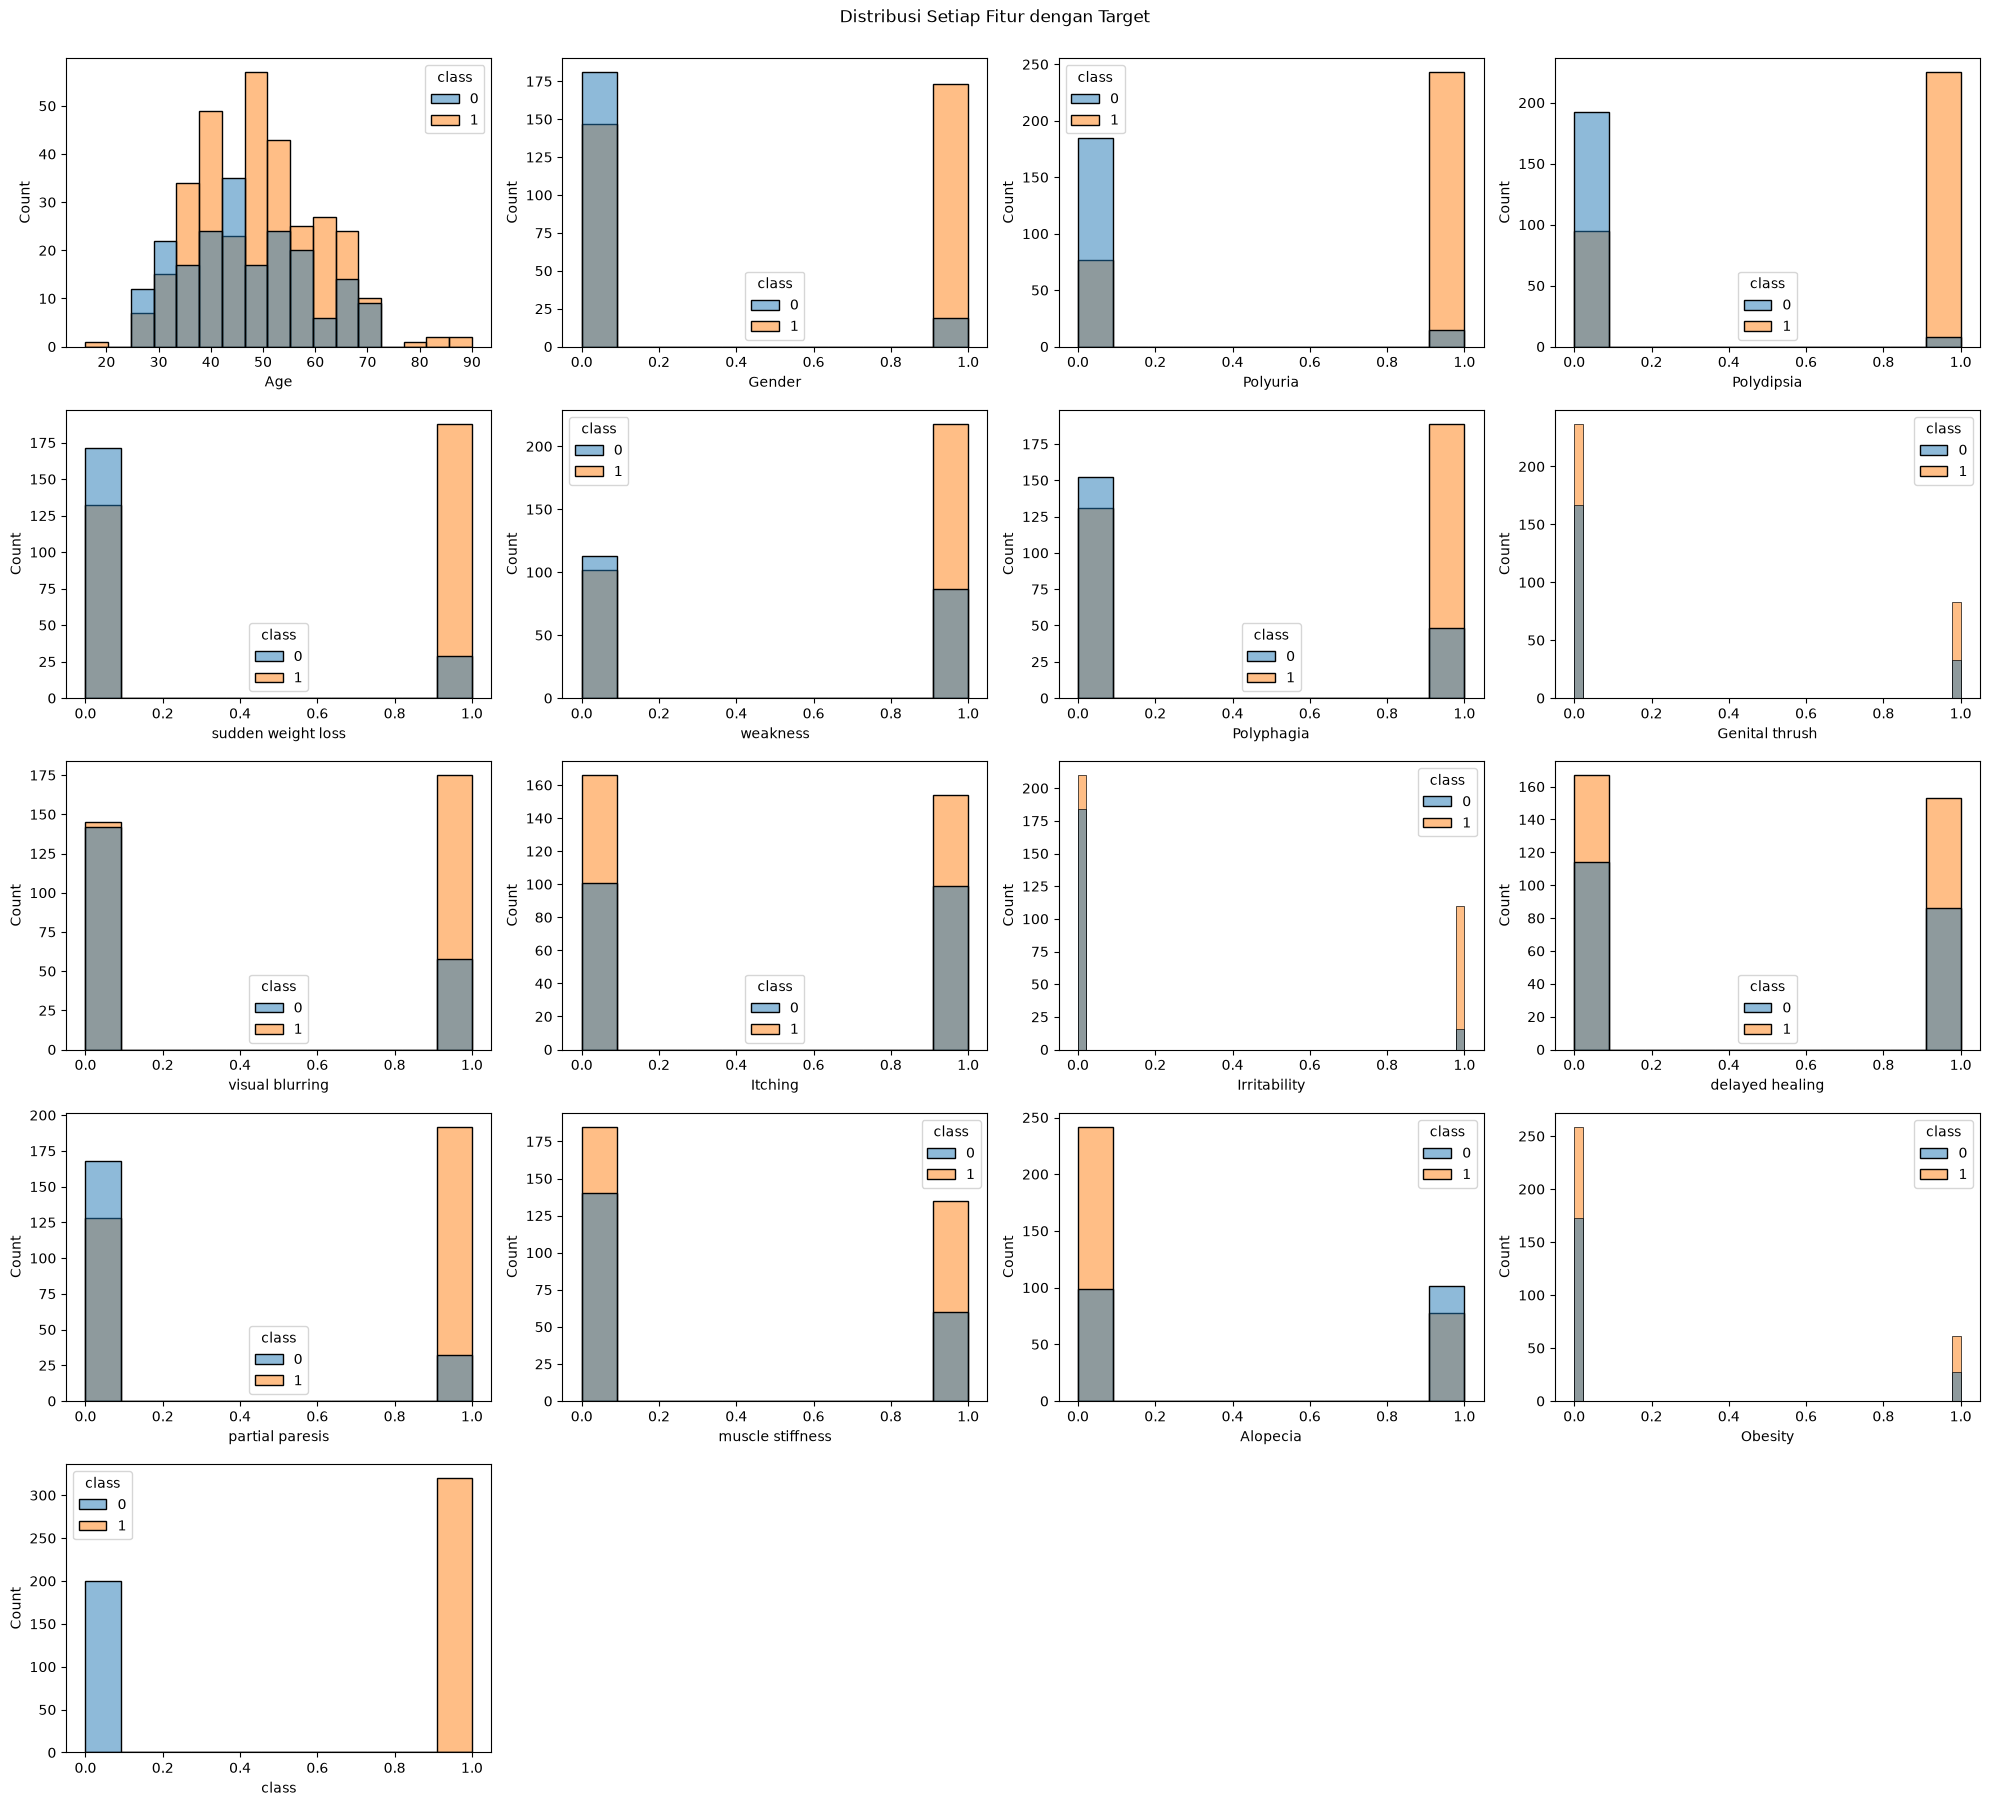

In [122]:
plt.figure(figsize=(20, 18))

for i, col in enumerate(dataset):
    plt.subplot(5, 4, i+1)
    sns.histplot(x=dataset[col], hue=dataset["class"])

plt.suptitle("Distribusi Setiap Fitur dengan Target", y=1.001)
plt.tight_layout()
plt.show()

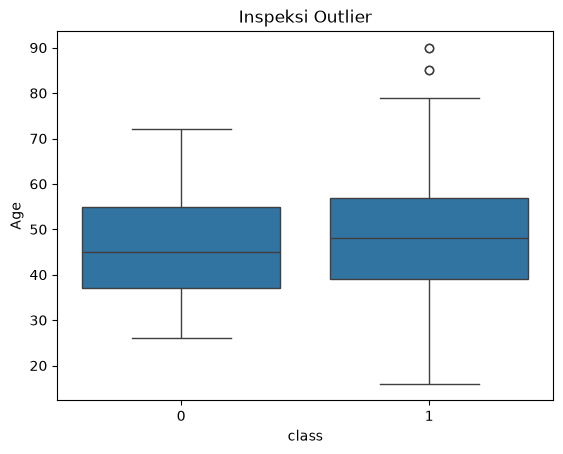

In [123]:
sns.boxplot(data=dataset, x="class", y="Age")
plt.title("Inspeksi Outlier")
plt.show()

Korelasi Matriks Kendall:
class                 1.000000
Polyuria              0.665922
Polydipsia            0.648734
Gender                0.449233
sudden weight loss    0.436568
partial paresis       0.432288
Polyphagia            0.342504
Irritability          0.299467
visual blurring       0.251300
weakness              0.243275
muscle stiffness      0.122474
Genital thrush        0.110288
Age                   0.091003
Obesity               0.072173
delayed healing       0.046980
Itching              -0.013384
Alopecia             -0.267512
Name: class, dtype: float64


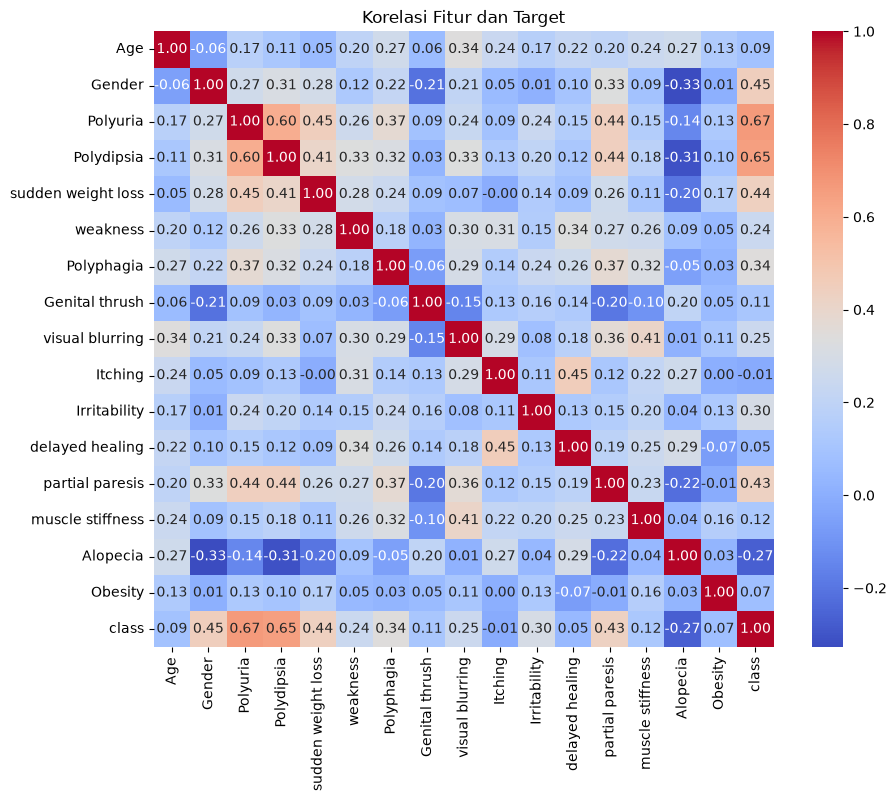

In [124]:
kendall_cor = dataset.corr(method='kendall')
print("Korelasi Matriks Kendall:")
print(kendall_cor['class'].sort_values(ascending=False))

plt.figure(figsize=(10,8))
sns.heatmap(kendall_cor, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Korelasi Fitur dan Target")
plt.show()

III. PREPROCESSING

In [125]:
dataset.dtypes

Age                    int64
Gender                 int64
Polyuria              object
Polydipsia            object
sudden weight loss    object
weakness              object
Polyphagia            object
Genital thrush        object
visual blurring       object
Itching               object
Irritability          object
delayed healing       object
partial paresis       object
muscle stiffness      object
Alopecia              object
Obesity               object
class                  int64
dtype: object

In [126]:
dataset = dataset.astype(int)

In [127]:
dataset.dtypes

Age                   int64
Gender                int64
Polyuria              int64
Polydipsia            int64
sudden weight loss    int64
weakness              int64
Polyphagia            int64
Genital thrush        int64
visual blurring       int64
Itching               int64
Irritability          int64
delayed healing       int64
partial paresis       int64
muscle stiffness      int64
Alopecia              int64
Obesity               int64
class                 int64
dtype: object

In [128]:
X = dataset.drop('class', axis=1).values
y = dataset['class'].values.reshape(-1,1)

1. Feature Scaling

In [129]:
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_scaled = (X - X_mean) / X_std

print("\nFitur sebelum scaling:")
print(X[:5])

print("\nFitur setelah scaling:")
print(X_scaled[:5])


Fitur sebelum scaling:
[[40  0  0  1  0  1  0  0  0  1  0  1  0  1  1  1]
 [58  0  0  0  0  1  0  0  1  0  0  0  1  0  1  0]
 [41  0  1  0  0  1  1  0  0  1  0  1  0  1  1  0]
 [45  0  0  0  1  1  1  1  0  1  0  1  0  0  0  0]
 [60  0  1  1  1  1  1  0  1  1  1  1  1  1  1  1]]

Fitur setelah scaling:
[[-0.6613669  -0.76509206 -0.99233705  1.10984668 -0.84626923  0.83959397
  -0.91512613 -0.53584393 -0.90102535  1.02729546 -0.56550593  1.08431186
  -0.86991767  1.29099445  1.38022749  2.21564684]
 [ 0.82136224 -0.76509206 -0.99233705 -0.90102535 -0.84626923  0.83959397
  -0.91512613 -0.53584393  1.10984668 -0.97342978 -0.56550593 -0.9222439
   1.14953407 -0.77459667  1.38022749 -0.45133547]
 [-0.57899306 -0.76509206  1.00772212 -0.90102535 -0.84626923  0.83959397
   1.09274555 -0.53584393 -0.90102535  1.02729546 -0.56550593  1.08431186
  -0.86991767  1.29099445  1.38022749 -0.45133547]
 [-0.24949769 -0.76509206 -0.99233705 -0.90102535  1.18165704  0.83959397
   1.09274555  1.86621505 

2. Split Data

In [130]:
m = len(X_scaled)
split = int(0.8 * m)

indices = np.arange(m)
np.random.shuffle(indices)

train_idx = indices[:split]
test_idx = indices[split:]

# ambil data sesuai index
X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (416, 16)
X_test : (104, 16)


IV. Modeling

In [131]:

# 2. DEFINE FUNCTIONS
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def train_logistic(X, y, lr=0.01, epochs=1000):
    m, n = X.shape
    w = np.zeros((n,1))
    b = 0
    losses = []

    for i in range(epochs):
        z = np.dot(X, w) + b
        y_pred = 1 / (1 + np.exp(-z))

        loss = -(1/m) * np.sum(y*np.log(y_pred+1e-8) + (1-y)*np.log(1-y_pred+1e-8))
        losses.append(loss)

        dw = (1/m) * np.dot(X.T, (y_pred - y))
        db = (1/m) * np.sum(y_pred - y)

        w -= lr * dw
        b -= lr * db

        if i % 100 == 0:
            print(f"Epoch {i}, Loss: {loss:.4f}")

    return w, b, losses

def predict(X, w, b):
    z = np.dot(X, w) + b
    y_pred = sigmoid(z)
    return (y_pred >= 0.5).astype(int)


In [132]:
w, b, losses = train_logistic(X_train, y_train, lr=0.1, epochs=1000)
y_pred = predict(X_test, w, b)
accuracy = np.mean(y_pred == y_test) * 100
print(f"Akurasi test: {accuracy:.2f}%")

Epoch 0, Loss: 0.6931
Epoch 100, Loss: 0.2575
Epoch 200, Loss: 0.2218
Epoch 300, Loss: 0.2056
Epoch 400, Loss: 0.1961
Epoch 500, Loss: 0.1898
Epoch 600, Loss: 0.1854
Epoch 700, Loss: 0.1820
Epoch 800, Loss: 0.1795
Epoch 900, Loss: 0.1774
Akurasi test: 91.35%


1. Loss vs Epoch

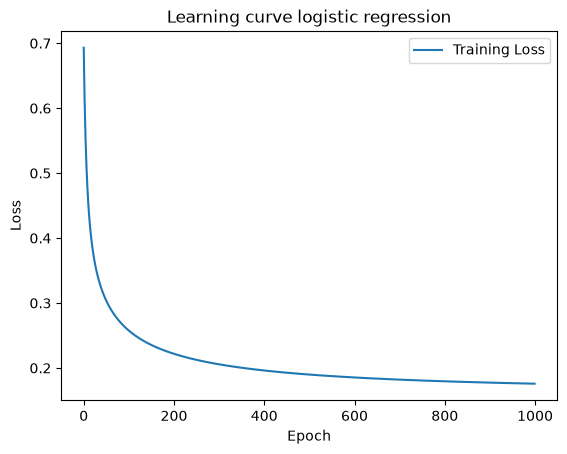

In [133]:
plt.plot(losses, label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning curve logistic regression")
plt.legend()
plt.show()

cara baca grafik di atas :
- titik awal 0.69 itu setara 50:50 >> normal buat awal training
- turun tajam di 0-100 epoch : optimizer cepat mnemukan arah yg benar > lagi belajar
- ke 200-300 epoch : loss masih turun, tapi semakin pelan
- disekitar 0.18 di epoch 1000, artinya rata2 prediksi untuk kelas bener cukup yakin (kira2 epoch 0.8-0.85)
- loss yg terus menurun itu baik tp blm menjamin dia overfitting atau underfitting

V. EVALUASI

1. Confusion Matrix

In [134]:
def confusion_matrix(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    return np.array([[TN, FP],
                     [FN, TP]])

def plot_confusion_matrix(cm):
    fig, ax = plt.subplots()
    im = ax.imshow(cm, cmap="Blues")

    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0,1])
    ax.set_yticks([0,1])
    ax.set_xticklabels(["0", "1"])
    ax.set_yticklabels(["0", "1"])

    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="black", fontsize=12)

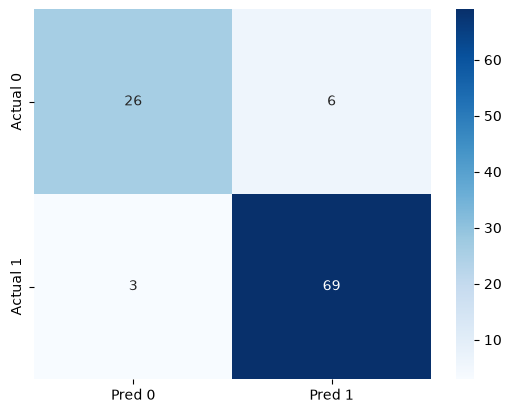

In [135]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred 0','Pred 1'], yticklabels=['Actual 0','Actual 1'])
plt.show()

In [136]:
def evaluate_model(y_true, y_pred, dataset_name="Dataset"):
    cm = confusion_matrix(y_true, y_pred)
    total = np.sum(cm)

    accuracy  = (cm[0,0] + cm[1,1]) / total
    precision = cm[1,1] / (cm[0,1] + cm[1,1]) if (cm[0,1] + cm[1,1]) > 0 else 0
    recall    = cm[1,1] / (cm[1,0] + cm[1,1]) if (cm[1,0] + cm[1,1]) > 0 else 0
    f1_score  = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    print(f"\n=== Evaluasi {dataset_name} ===")
    print("Confusion Matrix:\n", cm)
    print(f"Akurasi  : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1_score:.4f}")

evaluate_model(y_test, y_pred, "Test Set")


=== Evaluasi Test Set ===
Confusion Matrix:
 [[26  6]
 [ 3 69]]
Akurasi  : 0.9135
Precision: 0.9200
Recall   : 0.9583
F1-Score : 0.9388


2. ROC Auc

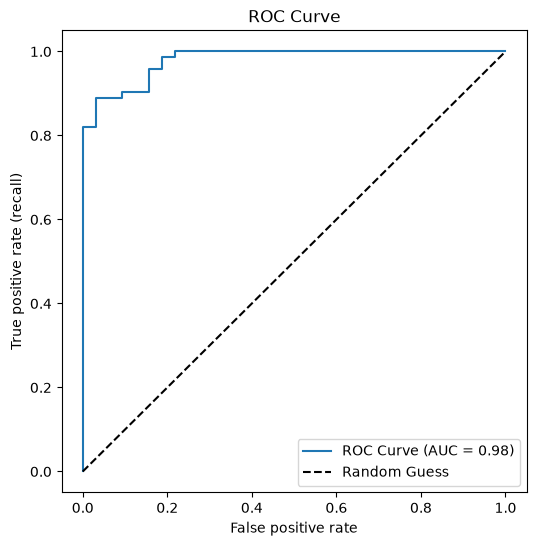

In [138]:

def compute_roc_auc(y_true, y_scores):
    # Flatten untuk menghindari error dimensi matriks
    y_true = y_true.flatten()
    y_scores = y_scores.flatten()
    
    desc_score_indices = np.argsort(-y_scores)
    y_true = y_true[desc_score_indices]
    y_scores = y_scores[desc_score_indices]

    tpr = []
    fpr = []
    P = np.sum(y_true == 1)
    N = np.sum(y_true == 0)

    TP = 0
    FP = 0

    for i in range(len(y_true)):
        if y_true[i] == 1:
            TP += 1
        else:
            FP += 1
        tpr.append(TP / P)
        fpr.append(FP / N)

    # ⚠️ PERHATIKAN INDENTASI: Bagian ini HARUS di luar 'for' loop!
    tpr = [0] + tpr + [1]
    fpr = [0] + fpr + [1]
    
    # Gunakan np.trapezoid (np.trapz sudah dihapus di NumPy 2.0)
    # Typo 'aus' diperbaiki menjadi 'auc'
    auc = np.trapezoid(tpr, fpr)

    return np.array(fpr), np.array(tpr), auc
    
def plot_auc_curve(y_true, y_scores):
    fpr, tpr, auc = compute_roc_auc(y_true, y_scores)
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc:.2f})")
    plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate (recall)")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

# Menghitung probabilitas
y_pred_prob = sigmoid(np.dot(X_test, w) + b)

# Langsung tampilkan plot dan AUC-nya!
plot_auc_curve(y_test, y_pred_prob)

VI. FEATURE IMPORTANCE

               Feature  Coefficient  Odds_Ratio
3           Polydipsia     1.746689    5.735579
2             Polyuria     1.650249    5.208277
1               Gender     1.483554    4.408587
9              Itching    -0.805040    0.447070
10        Irritability     0.715234    2.044666
7       Genital thrush     0.566147    1.761467
12     partial paresis     0.478778    1.614100
11     delayed healing    -0.400566    0.669941
5             weakness     0.339570    1.404343
0                  Age    -0.322611    0.724255
8      visual blurring     0.299045    1.348571
4   sudden weight loss     0.260330    1.297359
6           Polyphagia     0.198409    1.219461
13    muscle stiffness    -0.141885    0.867721
15             Obesity    -0.039261    0.961499
14            Alopecia     0.034283    1.034878


C:\Users\nizam\AppData\Local\Temp\ipykernel_14932\16207490.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=feature_importance, palette='viridis')


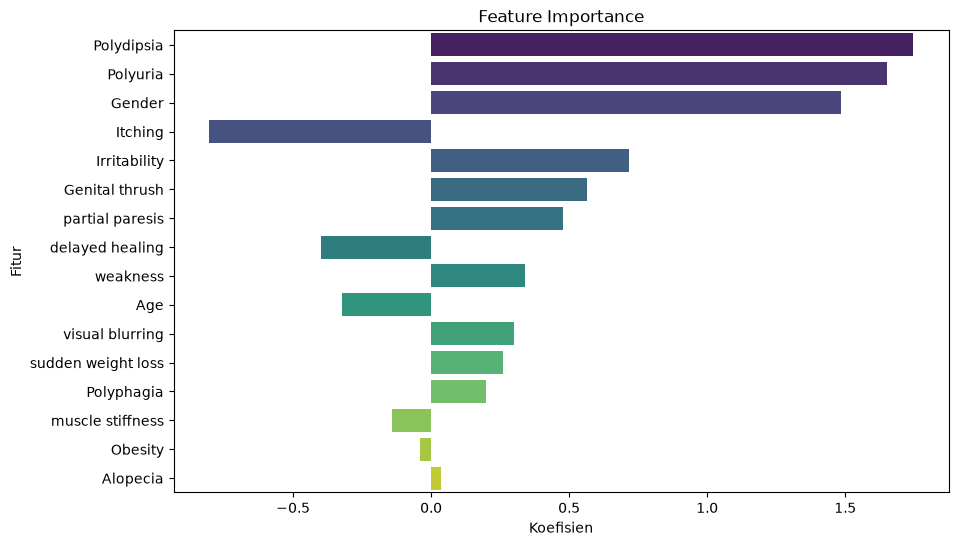

In [139]:
feature_names = dataset.columns.drop('class')
coef = w.flatten()

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coef,
    'Odds_Ratio': np.exp(coef)
})

feature_importance['abs_coef'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values(by='abs_coef', ascending=False)

print(feature_importance[['Feature', 'Coefficient', 'Odds_Ratio']])

plt.figure(figsize=(10,6))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance, palette='viridis')
plt.title("Feature Importance")
plt.xlabel("Koefisien")
plt.ylabel("Fitur")
plt.show()